# Aurora vs Base-Model: Variability, Accuracy & Timing

We’ll run each of the 20 ground-truth queries 5 times against:

1. **Aurora** endpoint (`/recommend`)  
2. **Raw LLM** endpoint (`/recommend_raw`)  

For each query we record:

- **Cosine‐similarity accuracy** (sentence‐level, after stripping bullets/markdown)  
- **Precision / Recall / F1** on extracted course codes  
- **Response times**  

And then plot:

1. **Boxplot** of Aurora times per query (with Raw mean overlaid)  
2. **Boxplot** of Aurora similarities per query (with Raw mean overlaid)  
3. **Bar chart** comparing mean accuracy (Aurora vs Raw)  
4. **Grouped bar chart** of Aurora’s accuracy, precision, recall, F1 per query  


In [ ]:
# ╔═ 1. Imports & constants ════════════════════════════════════════╗
import pandas as pd
import numpy as np
import requests, time, re, pickle, os
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import json
from typing import Tuple, List

# 1) hardcode where punkt lives, then load it _without_ nltk
PUNKT_PATH = r"C:\Users\roblo\AppData\Roaming\nltk_data\tokenizers\punkt\english.pickle"
with open(PUNKT_PATH, "rb") as f:
    _pkt = pickle.load(f)

def sent_tokenize_direct(text: str) -> list[str]:
    return _pkt.tokenize(text)

# sanity check
print(sent_tokenize_direct("This is the first sentence. And here’s the second!"))

# Endpoints & runs
AURORA_URL = "http://localhost:8010/recommend"
RAW_URL    = "http://localhost:8011/recommend_raw"
N_RUNS     = 5
EMBED_MODEL = "all-mpnet-base-v2"
# ╚═══════════════════════════════════════════════════════════════╝


c:\Users\roblo\anaconda3\envs\deep_learning_0401\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['This is the first sentence.', 'And here’s the second!']


In [2]:
# ╔═ 2. Helper functions: cleaning & extraction ═══════════════════╔═╗
def cleanup_markdown(text: str) -> str:
    """
    Strip Markdown bullets, bold markers, 'Total:' lines and collapse whitespace.
    """
    # remove **bold** or __underline__
    out = re.sub(r"[*_]{1,2}", "", text)
    # drop bullet markers at beginning of lines
    out = re.sub(r"^[\-\•\*]\s*", "", out, flags=re.MULTILINE)
    # remove any "Total: xx credits" lines
    out = re.sub(r"^Total:.*$", "", out, flags=re.MULTILINE)
    # collapse multiple spaces / newlines
    out = re.sub(r"\s+\n", "\n", out).strip()
    return out

def sentence_list(text: str) -> list[str]:
    """
    First cleanup markdown, then split into sentences.
    """
    cleaned = cleanup_markdown(text)
    sents  = sent_tokenize_direct(cleaned)
    return [s.strip() for s in sents if s.strip()]

# parse the llm_response JSON and pull out the `advice` strings
def extract_advice_cell(cell: str) -> str:
    # if it's already a dict-like, skip json.loads
    j = json.loads(cell) if isinstance(cell, str) else cell
    return j.get("advice", "")
# ╚════════════════════════════════════════════════════════════════╝


In [3]:
# ╔═ 3. Load Ground Truth ═════════════════════════════════════════╗
gt_df      = pd.read_excel("Ground_Truth.xlsx")
queries    = gt_df["query"].astype(str).tolist()
gold_cells = gt_df["llm_response"].astype(str).tolist()
user_ids   = gt_df["user_id"].astype(int).tolist()
# ╚═══════════════════════════════════════════════════════════════╝


In [4]:
# ╔═ 4. Initialize embedding model ════════════════════════════════╗
embedder = SentenceTransformer(EMBED_MODEL)
# ╚═══════════════════════════════════════════════════════════════╝


In [5]:
# ╔═ 5. HTTP caller with timing ═══════════════════════════════════╗
def call_endpoint(text: str, url: str, user_id: int) -> tuple[dict, float]:
    start = time.time()
    r = requests.post(url, json={"q": text, "user_id": user_id})
    elapsed = time.time() - start
    r.raise_for_status()
    payload = r.json()     # <-- full JSON: {'advice':…, 'plan':…, 'long_term':…}
    return payload, elapsed
# ╚═══════════════════════════════════════════════════════════════╝


In [6]:
# ╔═ 6. Metrics (embed + code extraction) ═════════════════════════╗
def cosine_acc_whole(pred: str, gold: str) -> float:
    emb = embedder.encode([pred, gold], convert_to_tensor=True)
    return float(util.cos_sim(emb[0], emb[1]))

# 1) remove *, `, [ ], ( ), { }, < >, commas, semicolons, colons, periods, dashes…
_MD_PUNC = re.compile(r'[\*\`\[\]\(\)\{\}\<\>\,\;\:\.\-]')
# 2) collapse any run of non-alnum between DEPT (2–4 letters) and NUM (3–4 digits)
_SEP     = re.compile(r'\b([A-Z]{2,4})\W+(\d{3,4})\b')
# 3) final matcher for the normalized form DEPT_NUM
_CODE    = re.compile(r'\b([A-Z]{2,4})_(\d{3,4})\b')

def extract_course_codes(text: str) -> set[str]:
    """
    Pull DEPT_NUM tokens out of a free-text advice string.
    """
    # strip markdown/punc noise & uppercase
    clean = _MD_PUNC.sub(' ', text).upper()
    # normalize ANY run of non-alnum → single underscore
    clean = _SEP.sub(r'\1_\2', clean)
    # pull out exactly DEPT_NUM
    return { f"{m.group(1)}_{m.group(2)}"
             for m in _CODE.finditer(clean) }

def extract_courses(cell: str) -> set[str]:
    """
    If `cell` is JSON with a "plan" array, take codes from plan;
    otherwise fall back to extracting codes from the advice text.
    """
    # 1) If it's already a dict, grab plan immediately
    plan = None
    if isinstance(cell, dict):
        plan = cell.get("plan", None)
    # 2) Otherwise if it's a JSON string, parse out the plan
    elif isinstance(cell, str):
        try:
            doc = json.loads(cell)
            plan = doc.get("plan", None)
        except json.JSONDecodeError:
            plan = None

    if isinstance(plan, list) and plan:
        return {
            code
            for sem in plan
            for code in sem.get("courses", [])
        }

    # fallback: pull codes out of the advice text
    if isinstance(cell, dict):
        advice = cell.get("advice", "")
    elif isinstance(cell, str):
        advice = cell
    else:
        advice = ""

    return extract_course_codes(advice)

def prf1_codes(pred_cell: str, gold_cell: str) -> tuple[float, float, float]:
    """
    Compute (precision, recall, f1) on the two sets from extract_courses().
    """
    pc = extract_courses(pred_cell)
    gc = extract_courses(gold_cell)
    
    # if *both* gold and pred are empty → true negative → perfect score
    if not pc and not gc:
        return 1.0, 1.0, 1.0
    
    tp = len(pc & gc)

    p = tp/len(pc) if pc else 0.0
    r = tp/len(gc) if gc else 0.0
    f1 = 2*p*r/(p+r) if (p+r)>0 else 0.0

    return p, r, f1
# ╚═══════════════════════════════════════════════════════════════╝


In [ ]:
# ── Test run on queries 1 & 2 only ────────────────────────────────────────────────

test_results = []
for idx, (q, gold_cell, uid) in enumerate(zip(queries, gold_cells, user_ids)):
    if idx >= 2:
        break
    aurora_preds, aurora_times = [], []
    raw_preds,    raw_times    = [], []

    # dummy warm-up on these first two
    _ , _ = call_endpoint(q, AURORA_URL, uid)
    _ , _ = call_endpoint(q, RAW_URL,   uid)

    # Aurora: 15 runs
    for _ in range(N_RUNS):
        a, ta = call_endpoint(q, AURORA_URL, uid)
        aurora_preds.append(a); aurora_times.append(ta)

    # Raw-LLM: 1 run
    r, tr = call_endpoint(q, RAW_URL, uid)
    raw_preds.append(r); raw_times.append(tr)

    print(f"\n=== DEBUG Query {idx} ===")
    print("GOLD answer codes:   ", extract_courses(gold_cell))
    for run_i, a in enumerate(aurora_preds):
        print(f"AURORA run {run_i:2d} codes:  ", extract_courses(a))
    print("RAW-LLM codes:       ", extract_courses(raw_preds[0]))

    # compute metrics
    a_accs = [
        cosine_acc_whole(extract_advice_cell(p), extract_advice_cell(gold_cell))
        for p in aurora_preds
    ]
    r_accs = [
        cosine_acc_whole(extract_advice_cell(p), extract_advice_cell(gold_cell))
        for p in raw_preds
    ]
    a_prf1 = [prf1_codes(p, gold_cell) for p in aurora_preds]
    a_prec = [x[0] for x in a_prf1]
    a_rec  = [x[1] for x in a_prf1]
    a_f1   = [x[2] for x in a_prf1]

    # compute Raw-LLM’s P/R/F1 on codes
    raw_prec, raw_rec, raw_f1 = prf1_codes(raw_preds[0], gold_cell)

    test_results.append({
        "query_index":    idx,
        "query":          q,
        "aurora_time_all":   aurora_times,
        "aurora_time_mean":  np.mean(aurora_times),
        "raw_time":          tr,
        "aurora_acc_mean":   np.mean(a_accs),
        "raw_acc":           r_accs[0],
        "raw_prec":       raw_prec,
        "raw_rec":        raw_rec,
        "raw_f1":         raw_f1,
        "aurora_prec_mean":  np.mean(a_prec),
        "aurora_rec_mean":   np.mean(a_rec),
        "aurora_f1_mean":    np.mean(a_f1),
    })

# Turn into a DataFrame and show
test_df = pd.DataFrame(test_results)
test_df



=== DEBUG Query 0 ===
GOLD answer codes:    {'MAD_3512', 'COT_4521', 'CAP_4630', 'MAD_3401', 'CIS_3950'}
AURORA run  0 codes:   {'MAD_3512', 'COT_4521', 'CAP_4630', 'MAD_3401', 'CGS_1920', 'CIS_3950'}
AURORA run  1 codes:   {'MAD_3512', 'COT_4521', 'CAP_4630', 'MAD_3401', 'CGS_1920', 'CIS_3950'}
AURORA run  2 codes:   {'MAD_3512', 'COT_4521', 'CAP_4630', 'MAD_3401', 'CGS_1920', 'CIS_3950'}
AURORA run  3 codes:   {'MAD_3512', 'COT_4521', 'CAP_4630', 'MAD_3401', 'CGS_1920', 'CIS_3950'}
AURORA run  4 codes:   {'MAD_3512', 'COT_4521', 'CAP_4630', 'MAD_3401', 'CGS_1920', 'CIS_3950'}
RAW-LLM codes:        {'CS_101', 'PHYS_105', 'CS_201', 'ECON_102', 'MATH_205'}

=== DEBUG Query 1 ===
GOLD answer codes:    {'COP4710', 'CIS3950', 'CGS1920', 'CEN4021', 'COP4610', 'CIS4951', 'CNT4713', 'MAD3512', 'CAP4052', 'CAP4104', 'COP4555', 'COP4534'}
AURORA run  0 codes:   {'COP4710', 'CIS3950', 'CGS1920', 'CEN4021', 'COP4610', 'CIS4951', 'CNT4713', 'MAD3512', 'CAP4052', 'CAP4104', 'COP4555', 'COP4534'}
A

,query_index,query,aurora_time_all,aurora_time_mean,raw_time,aurora_acc_mean,raw_acc,raw_prec,raw_rec,raw_f1,aurora_prec_mean,aurora_rec_mean,aurora_f1_mean
0,0,"{\n ""q"":\t""What courses should I take next ...","[29.559685230255127, 29.54297161102295, 29.577...",29.552663,13.454667,0.971835,0.821429,0.0,0.0,0.0,0.833333,1.0,0.909091
1,1,"{\n ""q"":\t""Plan the rest of my CS-BS degree...","[35.60833477973938, 35.51771068572998, 35.9910...",35.641101,13.295771,0.944961,0.598530,0.0,0.0,0.0,1.000000,1.0,1.000000


In [7]:
# ╔═ 7. Run evaluation loop ═══════════════════════════════════════╗
test_results = []
for idx, (q, gold_cell, uid) in enumerate(
        tqdm(zip(queries, gold_cells, user_ids),
             total=len(queries),
             desc="Running queries")):

    # collect Aurora outputs & times
    aurora_preds, aurora_times = [], []

    # warm‐up call for both endpoints
    _ , _ = call_endpoint(q, AURORA_URL, uid)
    _ , _ = call_endpoint(q, RAW_URL,   uid)

    # Aurora: N_RUNS runs
    for _ in range(N_RUNS):
        a, ta = call_endpoint(q, AURORA_URL, uid)
        aurora_preds.append(a)
        aurora_times.append(ta)

    # Raw LLM: single run
    raw_pred, raw_time = call_endpoint(q, RAW_URL, uid)

    # DEBUG: show extracted codes
    print(f"\n=== DEBUG Query {idx} ===")
    print("GOLD answer codes:   ", extract_courses(gold_cell))
    for run_i, a in enumerate(aurora_preds):
        print(f"AURORA run {run_i:2d} codes:  ", extract_courses(a))
    print("RAW-LLM codes:       ", extract_courses(raw_pred))

    # compute Aurora metrics
    a_accs  = [
        cosine_acc_whole(
            extract_advice_cell(p),
            extract_advice_cell(gold_cell)
        )
        for p in aurora_preds
    ]
    a_prf1  = [prf1_codes(p, gold_cell) for p in aurora_preds]
    a_prec  = [x[0] for x in a_prf1]
    a_rec   = [x[1] for x in a_prf1]
    a_f1    = [x[2] for x in a_prf1]

    # compute Raw LLM metrics
    raw_acc = cosine_acc_whole(
        extract_advice_cell(raw_pred),
        extract_advice_cell(gold_cell)
    )
    raw_prec, raw_rec, raw_f1 = prf1_codes(raw_pred, gold_cell)

    # record all results
    test_results.append({
        "query_index":     idx,
        "query":           q,

        # Aurora timing & accuracy distributions
        "aurora_time_all": aurora_times,
        "aurora_acc_all":  a_accs,

        # Aurora means
        "aurora_time_mean": np.mean(aurora_times),
        "aurora_acc_mean":  np.mean(a_accs),

        # Raw-LLM single values
        "raw_time_mean":   raw_time,
        "raw_acc_mean":    raw_acc,

        # Raw-LLM P/R/F1
        "raw_prec":        raw_prec,
        "raw_rec":         raw_rec,
        "raw_f1":          raw_f1,

        # Aurora P/R/F1 means
        "aurora_prec_mean": np.mean(a_prec),
        "aurora_rec_mean":  np.mean(a_rec),
        "aurora_f1_mean":   np.mean(a_f1),
    })

# assemble into a DataFrame
test_df = pd.DataFrame(test_results)
test_df
# ╚═══════════════════════════════════════════════════════════════╝


Running queries:   0%|          | 0/20 [00:00<?, ?it/s]


=== DEBUG Query 0 ===
GOLD answer codes:    {'COT_4521', 'MAD_3512', 'CIS_3950', 'MAD_3401', 'CAP_4630'}
AURORA run  0 codes:   {'COT_4521', 'MAD_3512', 'CIS_3950', 'CGS_1920', 'MAD_3401', 'CAP_4630'}
AURORA run  1 codes:   {'MAD_3512', 'CAP_4641', 'CIS_3950', 'CGS_1920', 'CAP_4770', 'CAP_4630'}
AURORA run  2 codes:   {'MAD_3512', 'CAP_4641', 'CIS_3950', 'CGS_1920', 'CAP_4770', 'CAP_4630'}
AURORA run  3 codes:   {'MAD_3512', 'CAP_4641', 'CIS_3950', 'CGS_1920', 'CAP_4770', 'CAP_4630'}
AURORA run  4 codes:   {'MAD_3512', 'CAP_4641', 'CIS_3950', 'CGS_1920', 'CAP_4770', 'CAP_4630'}
RAW-LLM codes:        {'COMM_100', 'ENGR_101', 'MATH_215', 'CS_201'}


Running queries:   5%|▌         | 1/20 [04:03<1:16:58, 243.06s/it]


=== DEBUG Query 1 ===
GOLD answer codes:    {'CIS3950', 'COP4534', 'CGS1920', 'CAP4052', 'COP4710', 'CEN4021', 'COP4610', 'CIS4951', 'MAD3512', 'CNT4713', 'COP4555', 'CAP4104'}
AURORA run  0 codes:   {'CIS3950', 'COP4534', 'CGS1920', 'CAP4052', 'COP4710', 'CEN4021', 'COP4610', 'CIS4951', 'MAD3512', 'CNT4713', 'COP4555', 'CAP4104'}
AURORA run  1 codes:   {'CIS3950', 'COP4534', 'CGS1920', 'CAP4052', 'COP4710', 'CEN4021', 'COP4610', 'CIS4951', 'MAD3512', 'CNT4713', 'COP4555', 'CAP4104'}
AURORA run  2 codes:   {'CIS3950', 'COP4534', 'CGS1920', 'CAP4052', 'COP4710', 'CEN4021', 'COP4610', 'CIS4951', 'MAD3512', 'CNT4713', 'COP4555', 'CAP4104'}
AURORA run  3 codes:   {'CIS3950', 'COP4534', 'CGS1920', 'CAP4052', 'COP4710', 'CEN4021', 'COP4610', 'CIS4951', 'MAD3512', 'CNT4713', 'COP4555', 'CAP4104'}
AURORA run  4 codes:   {'CIS3950', 'COP4534', 'CGS1920', 'CAP4052', 'COP4710', 'CEN4021', 'COP4610', 'CIS4951', 'MAD3512', 'CNT4713', 'COP4555', 'CAP4104'}
RAW-LLM codes:        set()


Running queries:  10%|█         | 2/20 [08:21<1:15:34, 251.92s/it]

...


=== DEBUG Query 18 ===
GOLD answer codes:    set()
AURORA run  0 codes:   set()
AURORA run  1 codes:   set()
AURORA run  2 codes:   set()
AURORA run  3 codes:   set()
AURORA run  4 codes:   set()
RAW-LLM codes:        set()


Running queries:  95%|█████████▌| 19/20 [51:58<01:22, 82.87s/it]


=== DEBUG Query 19 ===
GOLD answer codes:    set()
AURORA run  0 codes:   set()
AURORA run  1 codes:   set()
AURORA run  2 codes:   set()
AURORA run  3 codes:   set()
AURORA run  4 codes:   set()
RAW-LLM codes:        set()


Running queries: 100%|██████████| 20/20 [52:49<00:00, 158.47s/it]


,query_index,query,aurora_time_all,aurora_acc_all,aurora_time_mean,aurora_acc_mean,raw_time_mean,raw_acc_mean,raw_prec,raw_rec,raw_f1,aurora_prec_mean,aurora_rec_mean,aurora_f1_mean
0,0,"{\n ""q"":\t""What courses should I take next ...","[30.642907857894897, 37.60680055618286, 37.511...","[0.9718347787857056, 0.9299755096435547, 0.929...",36.226673,0.938347,13.798836,0.826303,0.0,0.0,0.0,0.566667,0.680000,0.618182
1,1,"{\n ""q"":\t""Plan the rest of my CS-BS degree...","[38.468552589416504, 38.34213209152222, 38.141...","[0.9449614882469177, 0.9449614882469177, 0.944...",38.268852,0.944961,13.894730,0.735543,0.0,0.0,0.0,1.000000,1.000000,1.000000
2,2,"{\n ""q"":\t""I’d like an AI-oriented schedule...","[23.7727267742157, 23.69686460494995, 23.72691...","[0.9141643047332764, 0.9141643047332764, 0.914...",23.716725,0.914164,13.962040,0.732144,0.0,0.0,0.0,0.400000,0.400000,0.400000
3,3,"{\n ""q"":\t""Suggest five courses for Spring ...","[25.072973012924194, 24.984440803527832, 24.68...","[0.9576813578605652, 0.9576813578605652, 0.957...",24.765762,0.957681,14.033129,0.732359,0.0,0.0,0.0,1.000000,0.800000,0.888889
4,4,"{\n ""q"":\t""Plan my final academic year so I...","[23.692834615707397, 23.69566297531128, 23.690...","[0.8892996311187744, 0.8892996311187744, 0.889...",23.741494,0.889300,13.860379,0.516786,0.0,0.0,0.0,1.000000,1.000000,1.000000
5,5,"{\n ""q"": \t""Aurora, can you build a balance...","[22.74588441848755, 22.652565002441406, 22.953...","[0.9033392071723938, 0.9033392071723938, 0.903...",22.874053,0.903339,14.339532,0.583567,0.0,0.0,0.0,0.750000,0.750000,0.750000
6,6,"{\n ""q"": \t""Are there any courses I can tak...","[17.206472873687744, 17.19051957130432, 17.521...","[0.975208580493927, 0.975208580493927, 0.97520...",17.326187,0.975209,14.577782,0.506073,0.0,0.0,0.0,1.000000,1.000000,1.000000
7,7,"{\n ""q"": \t""I am feeling overwhelmed by cou...","[37.045198917388916, 39.35744905471802, 35.782...","[0.9299588203430176, 0.9299588203430176, 0.929...",36.798726,0.929959,13.856951,0.576877,0.0,0.0,0.0,0.571429,0.800000,0.666667
8,8,"{\n ""q"": \t""Which classes do I need to take...","[73.78272604942322, 72.19728779792786, 72.2367...","[0.9894036650657654, 0.9894036650657654, 0.989...",72.922553,0.989404,14.209154,0.698030,0.0,0.0,0.0,0.388889,1.000000,0.560000
9,9,"{\n ""q"": \t""What classes should I take if I...","[36.71213126182556, 36.7762610912323, 36.68380...","[0.9643029570579529, 0.9643029570579529, 0.964...",36.708841,0.964303,14.209191,0.824714,0.0,0.0,0.0,0.571429,0.800000,0.666667


In [9]:
import matplotlib as mpl

# ──────────────────────────────────────────────────────────────────────────
# Global style tweaks for higher-res / bigger text / thicker lines
# ──────────────────────────────────────────────────────────────────────────

# 1) bump DPI and default figure size
mpl.rcParams['figure.dpi']      = 200
mpl.rcParams['figure.figsize'] = (14, 6)

# 2) larger fonts
mpl.rcParams['font.size']        = 14
mpl.rcParams['axes.titlesize']   = 16
mpl.rcParams['axes.labelsize']   = 15
mpl.rcParams['xtick.labelsize']  = 12
mpl.rcParams['ytick.labelsize']  = 12
mpl.rcParams['legend.fontsize']  = 13

# 3) thicker lines everywhere
mpl.rcParams['lines.linewidth']      = 2
mpl.rcParams['boxplot.boxprops.linewidth']    = 2
mpl.rcParams['boxplot.whiskerprops.linewidth']= 2
mpl.rcParams['boxplot.capprops.linewidth']    = 2
mpl.rcParams['boxplot.medianprops.linewidth'] = 2
mpl.rcParams['grid.linewidth']              = 1

# 4) lighten the grid
mpl.rcParams['axes.grid']        = True
mpl.rcParams['grid.color']       = 'gray'
mpl.rcParams['grid.linestyle']   = '--'
mpl.rcParams['grid.alpha']       = 0.3
# ──────────────────────────────────────────────────────────────────────────


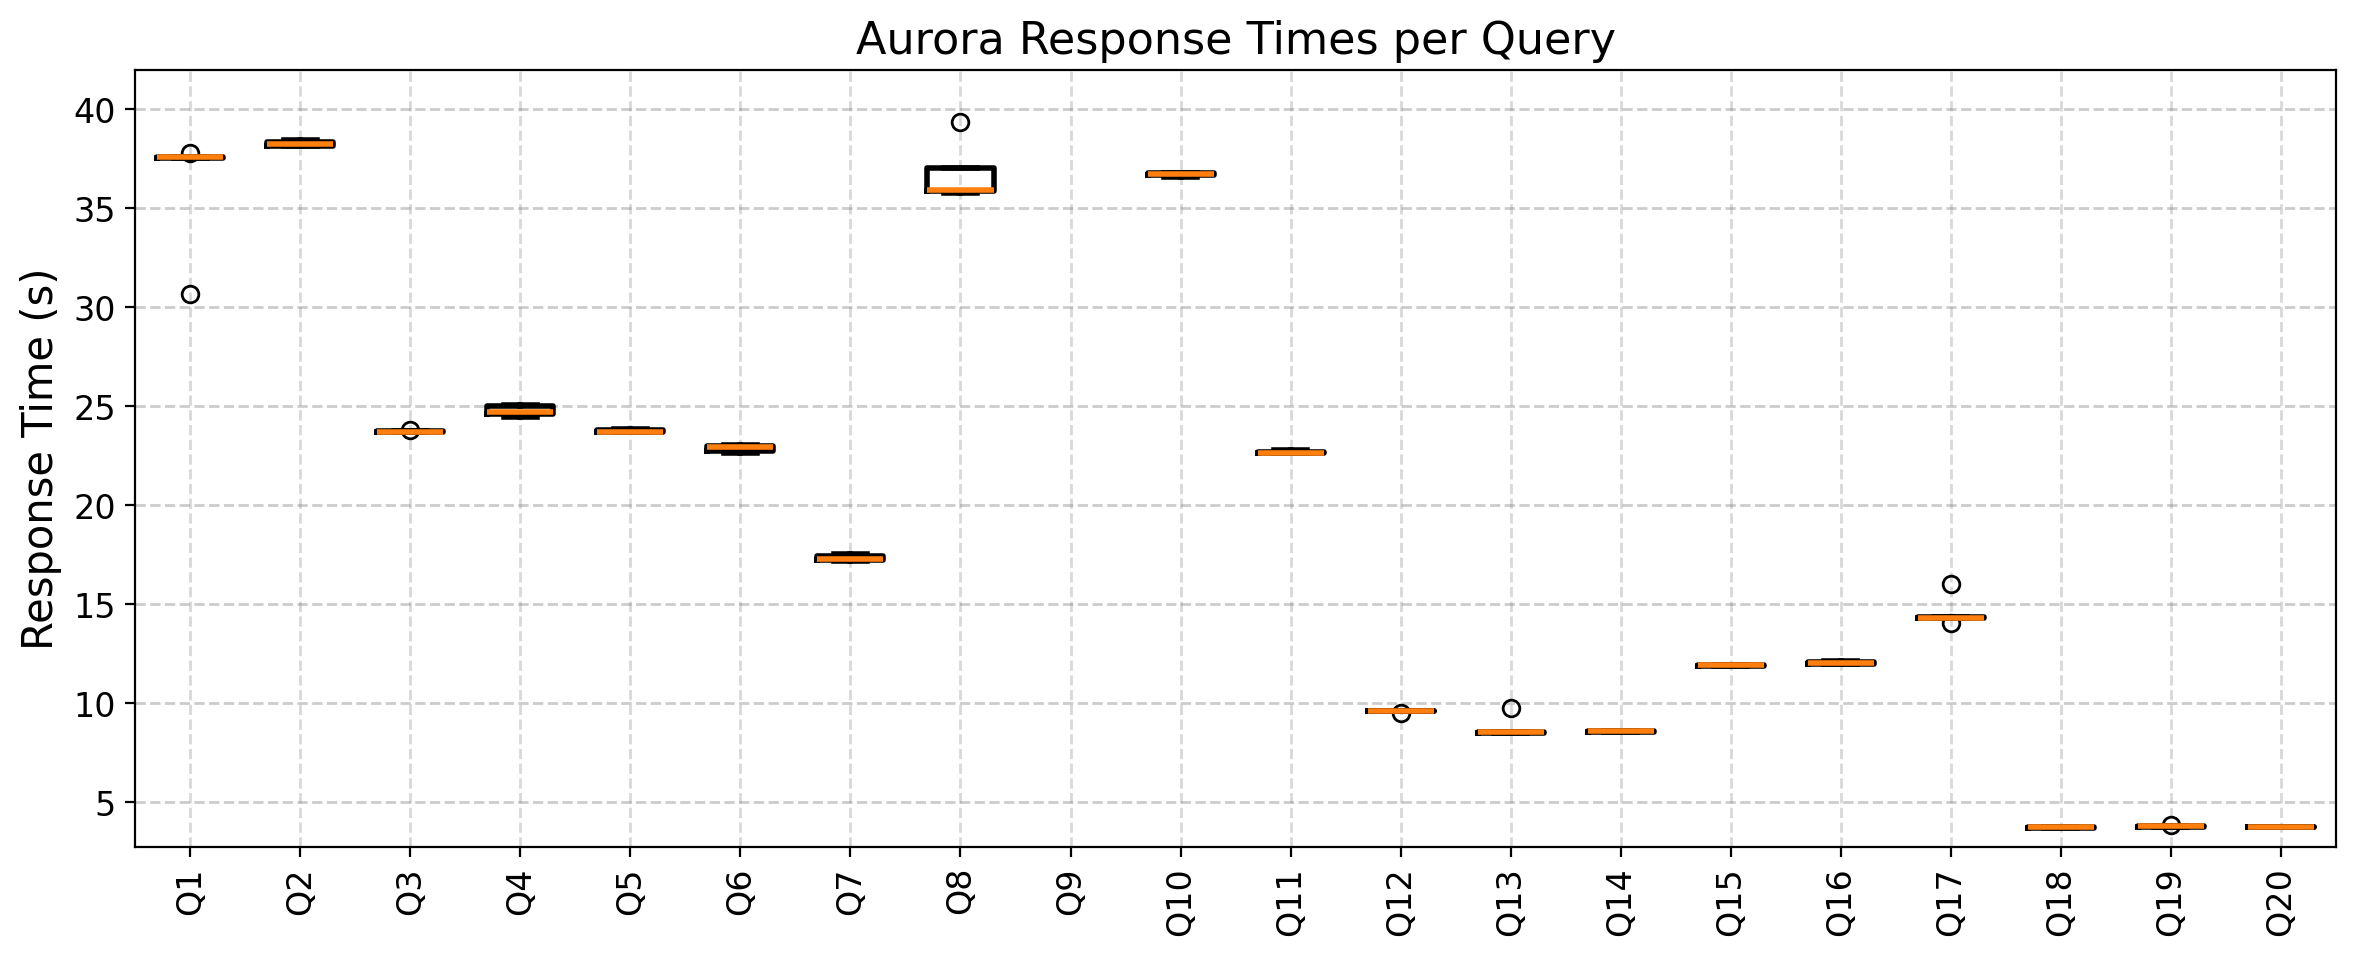

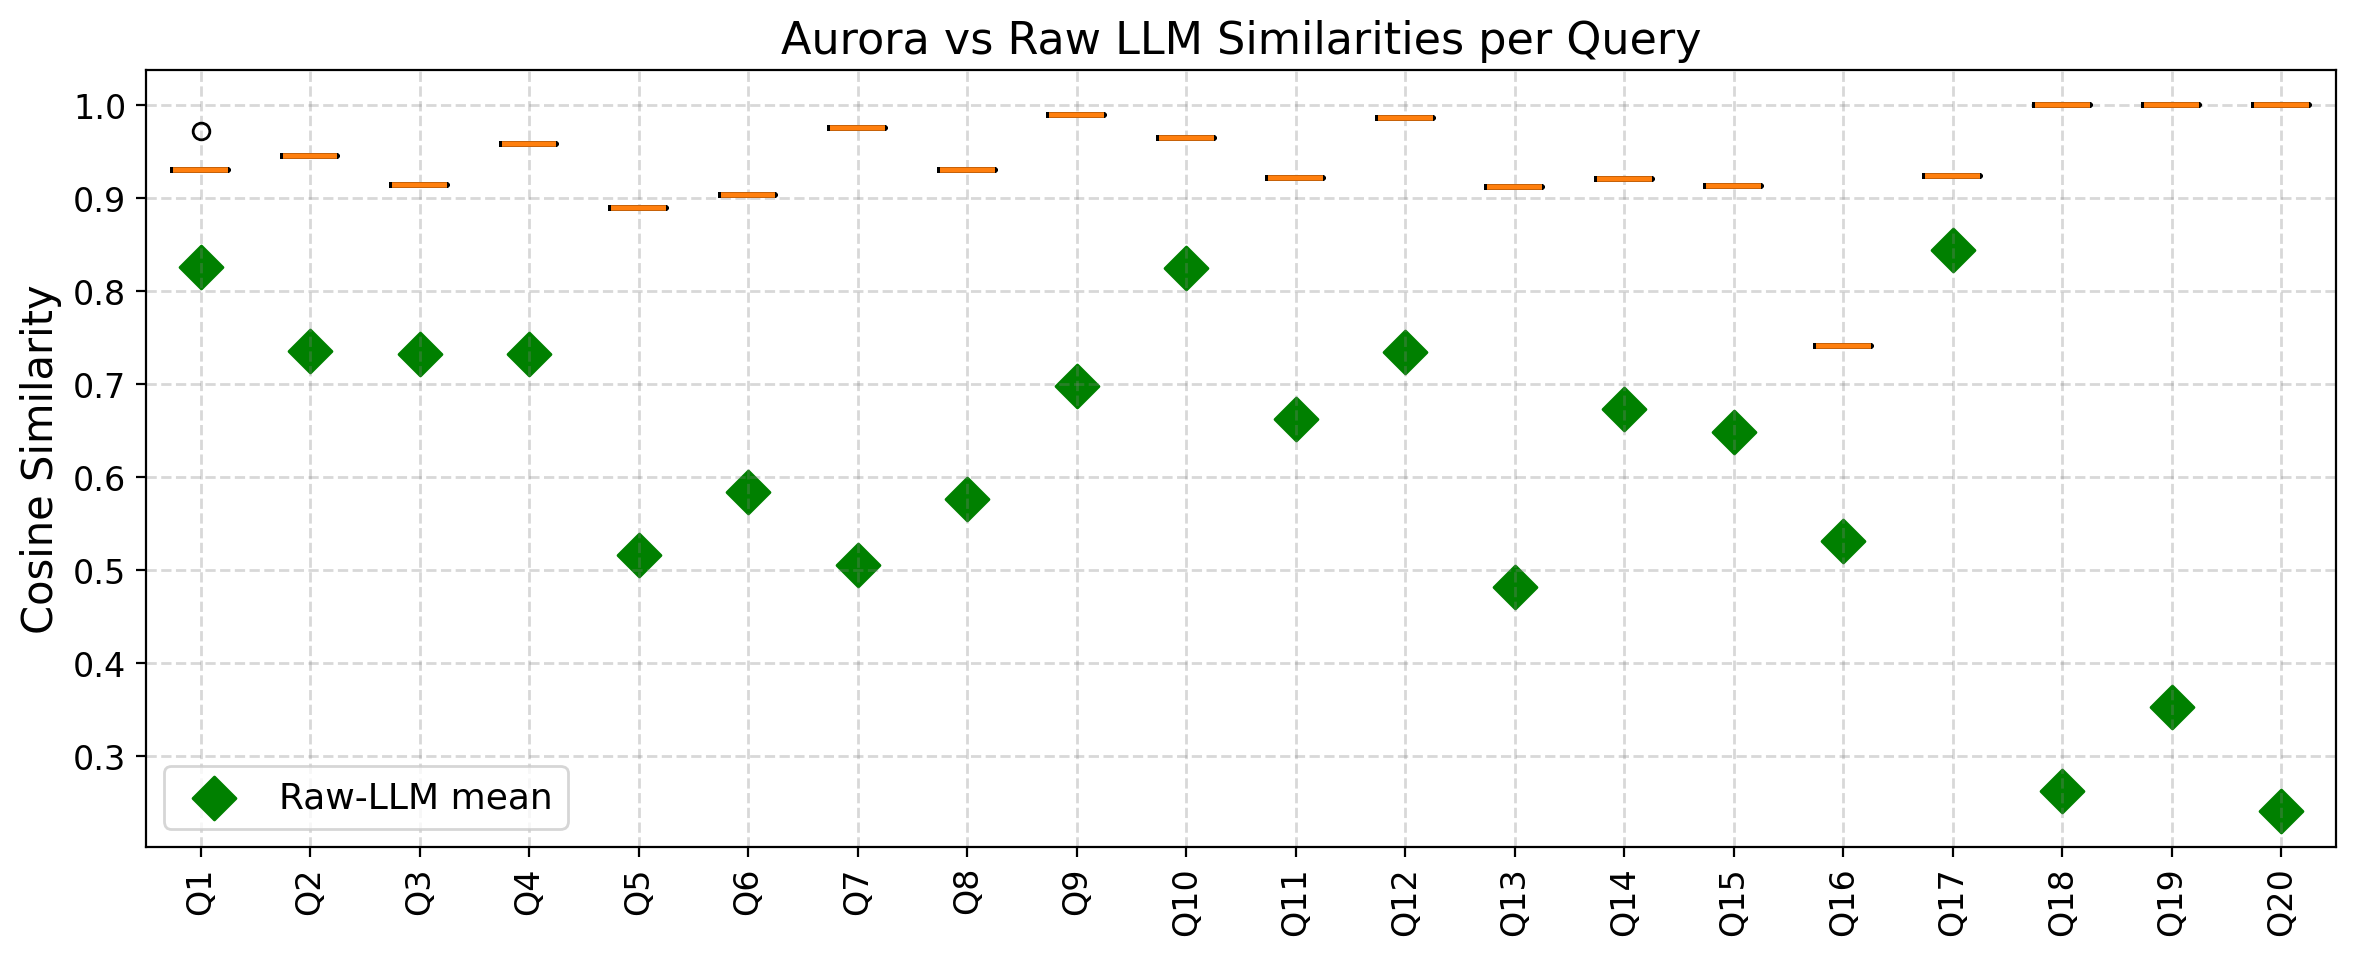

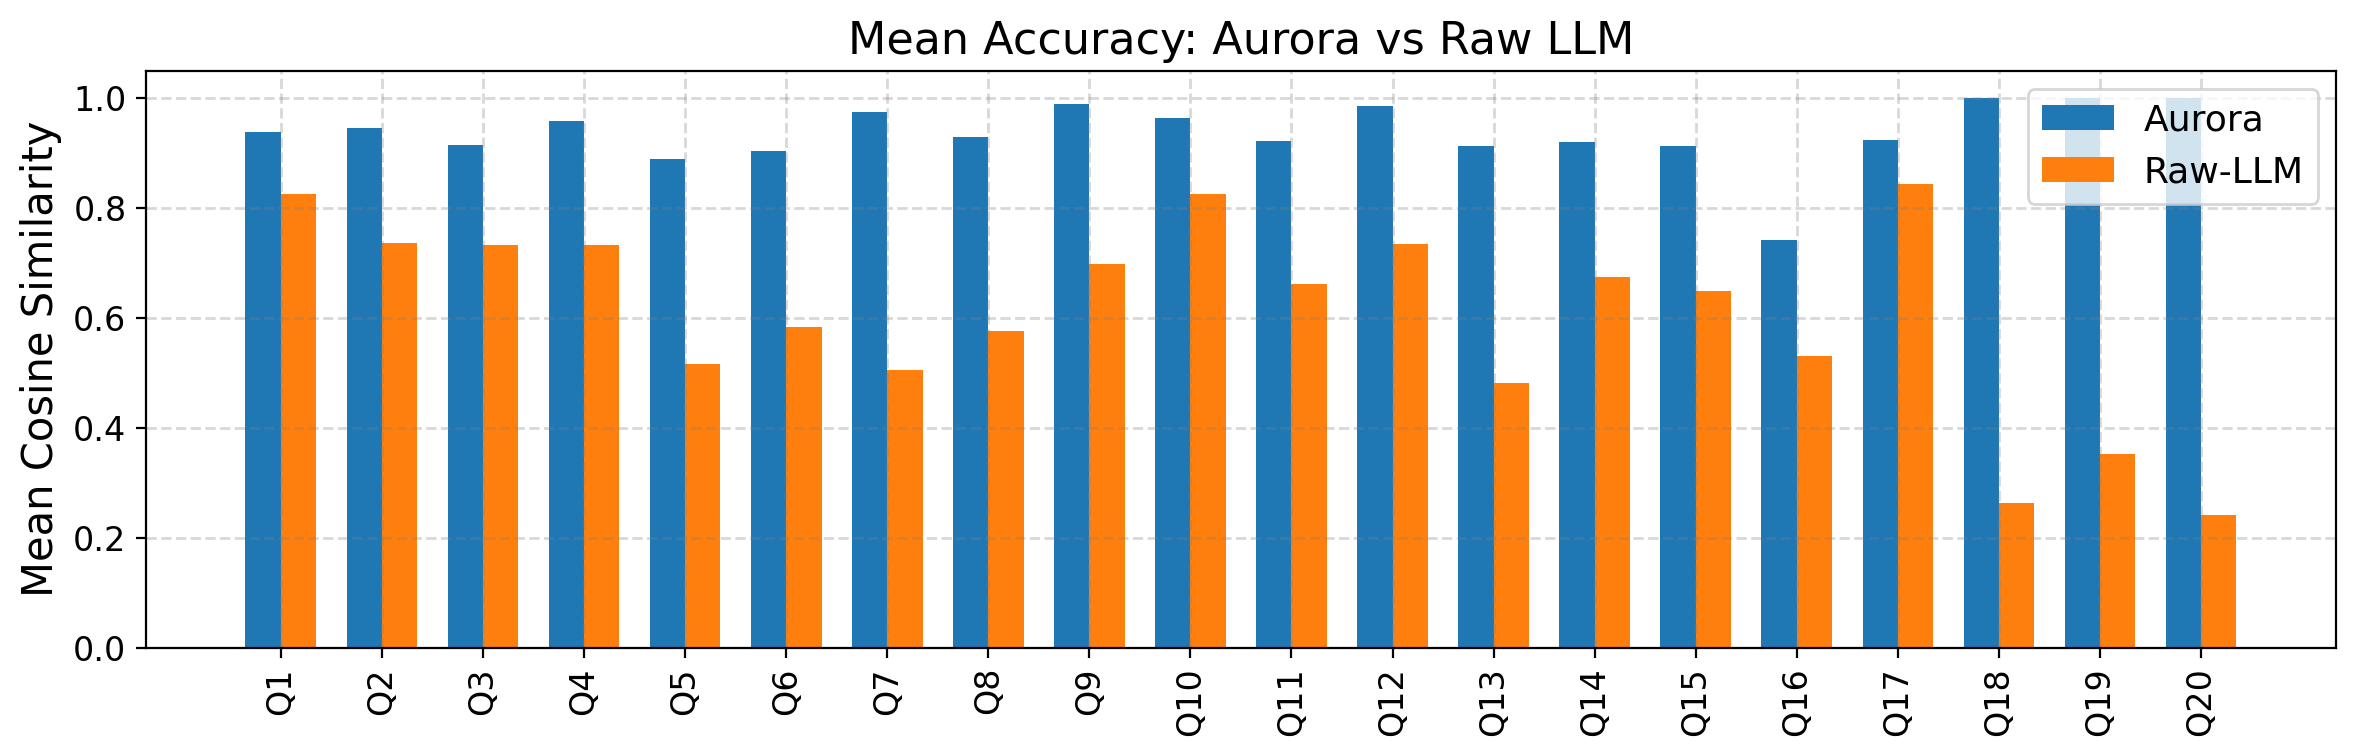

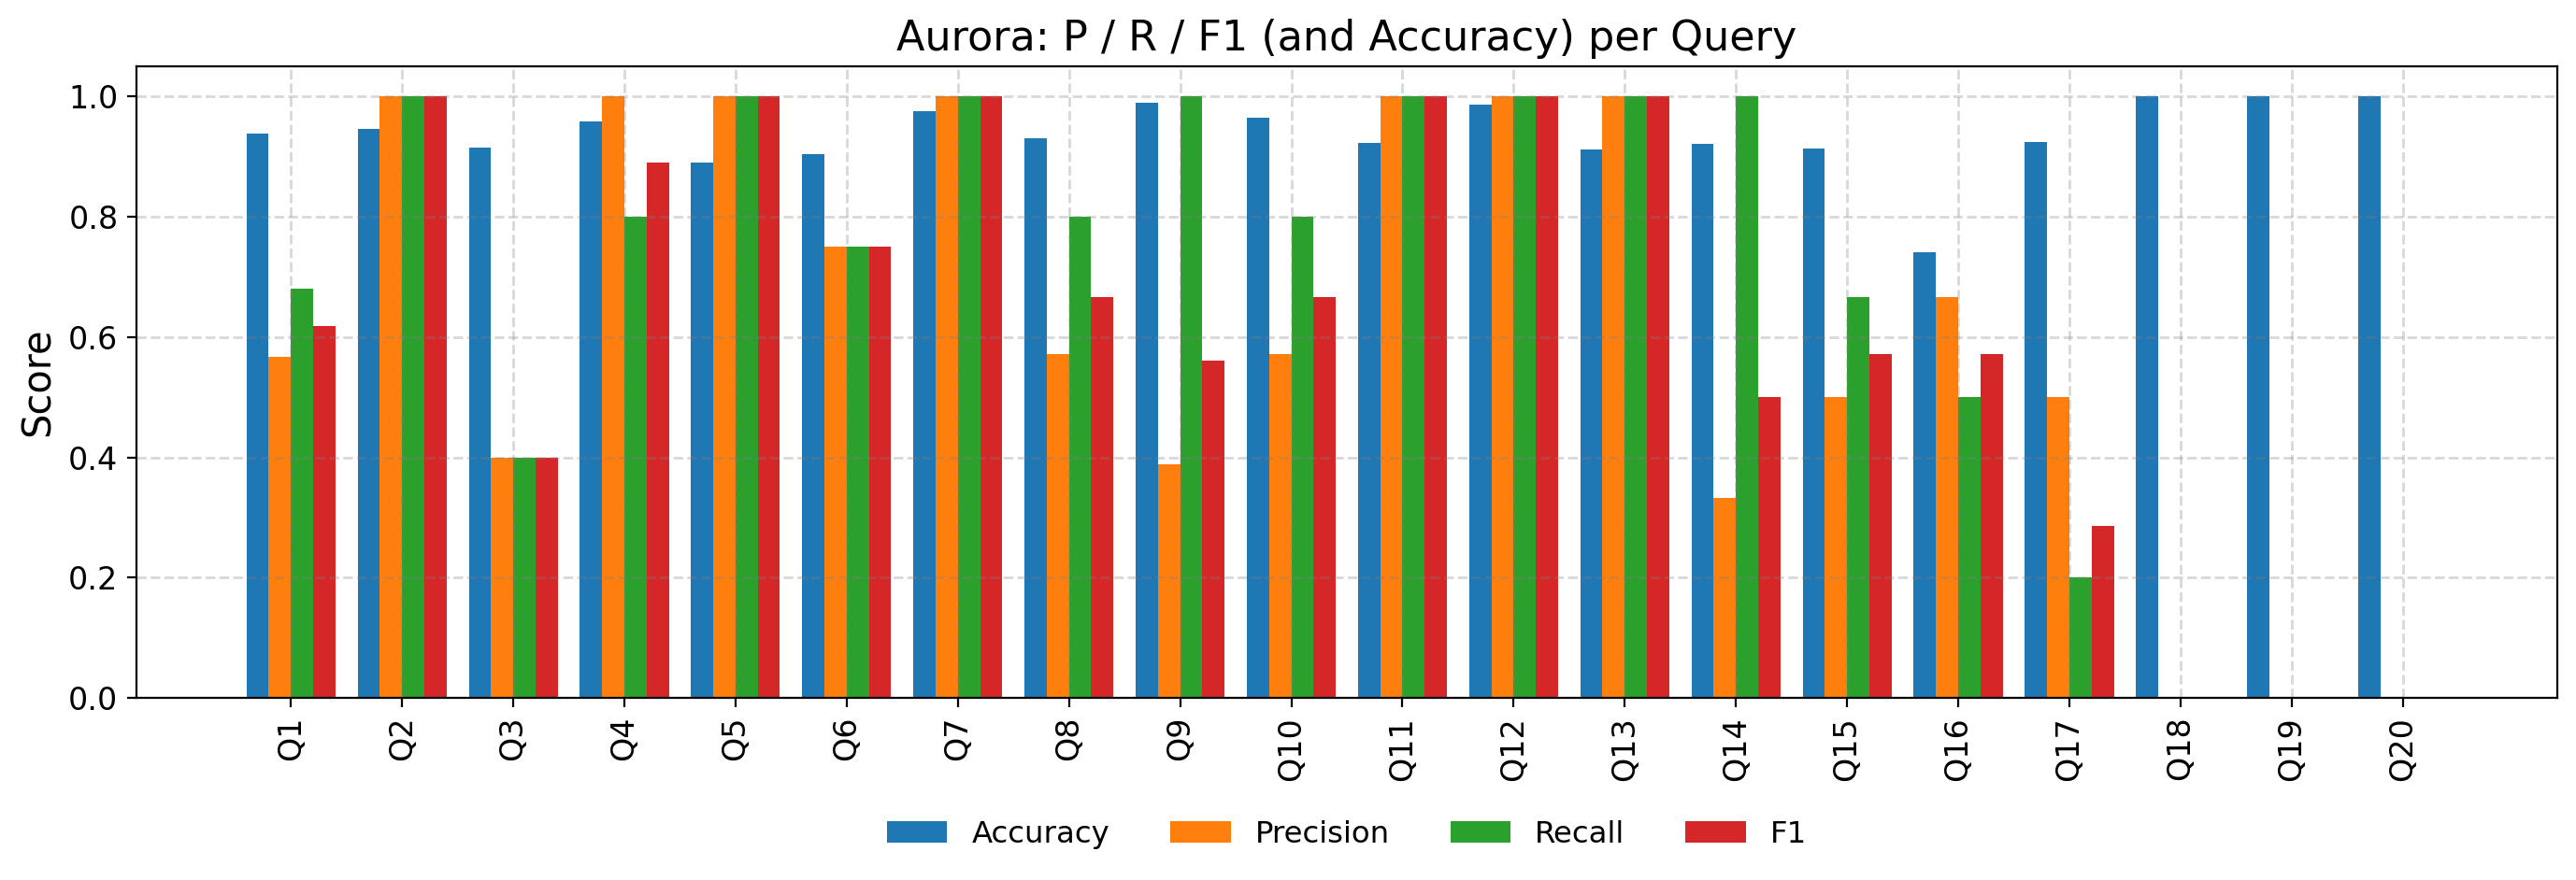

In [21]:
# ╔═ 8. Plotting ════════════════════════════════════════════════╗

# make sure your DataFrame is named `test_df` and has these columns:
#   • query_index
#   • aurora_time_all     (list of floats)
#   • raw_time_mean       (float)
#   • aurora_acc_all      (list of floats)
#   • raw_acc_mean        (float)
#   • aurora_acc_mean
#   • aurora_prec_mean
#   • aurora_rec_mean
#   • aurora_f1_mean

Q = len(test_df)
labels = [f"Q{i+1}" for i in test_df["query_index"]]

### 8.1 Aurora response times boxplot + Raw mean overlay
plt.figure(figsize=(12,5))
# 1) thicker boxes + lines
bp = plt.boxplot(
    test_df["aurora_time_all"].tolist(),
    widths=0.6,
    tick_labels=labels,
    boxprops   = dict(linewidth=2),
    whiskerprops=dict(linewidth=2),
    capprops   = dict(linewidth=2),
    medianprops=dict(linewidth=2)
)

# 2) no raw‐LLM overlay any more
# (we simply drop the plt.scatter call)

# 3) rotate x‐labels, title, etc.
plt.xticks(rotation=90)
plt.ylabel("Response Time (s)")
plt.title("Aurora Response Times per Query")

# 4) zoom y to 5th–95th percentile of all Aurora runs
all_times = np.concatenate(test_df["aurora_time_all"].tolist())
low, high = np.percentile(all_times, [5, 95])
plt.ylim(low - 1, high + 1)    # a bit of padding at top/bottom

# 5) optional light grid for readability
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


### 8.2 Aurora vs Raw cosine‐similarity boxplot + Raw point overlay
plt.figure(figsize=(12,5))
plt.boxplot(test_df["aurora_acc_all"].tolist(), tick_labels=labels)

plt.scatter(
    np.arange(1, Q+1),
    test_df["raw_acc_mean"],
    color="green",
    marker="D",
    s=120,                    # <-- bigger diamond
    label="Raw-LLM mean"
)

plt.xticks(rotation=90)
plt.ylabel("Cosine Similarity")
plt.title("Aurora vs Raw LLM Similarities per Query")
plt.legend()
plt.tight_layout()
plt.show()


### 8.3 Bar chart: mean accuracy Aurora vs Raw
x = np.arange(Q)
width = 0.35

plt.figure(figsize=(12,4))
plt.bar(x - width/2, test_df["aurora_acc_mean"],  width, label="Aurora")
plt.bar(x + width/2, test_df["raw_acc_mean"],    width, label="Raw-LLM")
plt.xticks(x, labels, rotation=90)
plt.ylabel("Mean Cosine Similarity")
plt.title("Mean Accuracy: Aurora vs Raw LLM")
plt.legend()
plt.tight_layout()
plt.show()


### 8.4 Grouped bar chart: Aurora’s metrics per query
metrics = [
    "aurora_acc_mean",
    "aurora_prec_mean",
    "aurora_rec_mean",
    "aurora_f1_mean",
]
metric_labels = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(Q)
width = 0.2

plt.figure(figsize=(14,5))
for i, (col, lbl) in enumerate(zip(metrics, metric_labels)):
    plt.bar(x + (i - 1.5)*width, test_df[col], width, label=lbl)

plt.xticks(x, labels, rotation=90)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Aurora: P / R / F1 (and Accuracy) per Query")

# improved legend
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=False,
    fontsize='small'
)

plt.tight_layout()
plt.show()

# ╚═══════════════════════════════════════════════════════════════╝


In [7]:
# ╔═ 7. Run evaluation in 5 cycles of 20 queries each ════════════╗
N_CYCLES = 5
test_results = []

for cycle in range(N_CYCLES):
    for idx, (q, gold_cell, uid) in enumerate(
            tqdm(zip(queries, gold_cells, user_ids),
                 total=len(queries),
                 desc=f"Cycle {cycle+1}/{N_CYCLES}")):

        # collect Aurora outputs & times
        aurora_preds, aurora_times = [], []

        # warm‐up call for both endpoints
        _ , _ = call_endpoint(q, AURORA_URL, uid)
        _ , _ = call_endpoint(q, RAW_URL,   uid)

        # Aurora: 1 run per query per cycle
        a, ta = call_endpoint(q, AURORA_URL, uid)
        aurora_preds.append(a)
        aurora_times.append(ta)

        # Raw LLM: single run
        raw_pred, raw_time = call_endpoint(q, RAW_URL, uid)

        # DEBUG: show extracted codes
        print(f"\n=== DEBUG Cycle {cycle+1} Query {idx} ===")
        print("GOLD answer codes:   ", extract_courses(gold_cell))
        print("AURORA codes:        ", extract_courses(a))
        print("RAW-LLM codes:       ", extract_courses(raw_pred))

        # compute Aurora metrics
        a_accs  = [
            cosine_acc_whole(
                extract_advice_cell(p),
                extract_advice_cell(gold_cell)
            )
            for p in aurora_preds
        ]
        a_prf1  = [prf1_codes(p, gold_cell) for p in aurora_preds]
        a_prec  = [x[0] for x in a_prf1]
        a_rec   = [x[1] for x in a_prf1]
        a_f1    = [x[2] for x in a_prf1]

        # compute Raw LLM metrics
        raw_acc = cosine_acc_whole(
            extract_advice_cell(raw_pred),
            extract_advice_cell(gold_cell)
        )
        raw_prec, raw_rec, raw_f1 = prf1_codes(raw_pred, gold_cell)

        # record all results
        test_results.append({
            "cycle":           cycle+1,
            "query_index":     idx,
            "query":           q,

            # Aurora timing & accuracy
            "aurora_time_all": aurora_times,
            "aurora_acc_all":  a_accs,
            "aurora_time_mean": np.mean(aurora_times),
            "aurora_acc_mean":  np.mean(a_accs),

            # Raw-LLM single values
            "raw_time_mean":   raw_time,
            "raw_acc_mean":    raw_acc,

            # Raw-LLM P/R/F1
            "raw_prec":        raw_prec,
            "raw_rec":         raw_rec,
            "raw_f1":          raw_f1,

            # Aurora P/R/F1 means
            "aurora_prec_mean": np.mean(a_prec),
            "aurora_rec_mean":  np.mean(a_rec),
            "aurora_f1_mean":   np.mean(a_f1),
        })

# assemble into a DataFrame
test_df = pd.DataFrame(test_results)
test_df
# ╚═══════════════════════════════════════════════════════════════╝


Cycle 1/5:   0%|          | 0/20 [00:00<?, ?it/s]


=== DEBUG Cycle 1 Query 0 ===
GOLD answer codes:    {'COT_4521', 'MAD_3512', 'CIS_3950', 'MAD_3401', 'CAP_4630'}
AURORA codes:         {'COT_4521', 'MAD_3512', 'CIS_3950', 'MAD_3401', 'CAP_4630', 'CGS_1920'}
RAW-LLM codes:        {'CS_201', 'MATH_205', 'PHYS_101', 'ECON_105'}


Cycle 1/5:   5%|▌         | 1/20 [01:26<27:29, 86.84s/it]


=== DEBUG Cycle 1 Query 1 ===
GOLD answer codes:    {'CIS4951', 'CAP4052', 'COP4555', 'COP4610', 'CGS1920', 'COP4710', 'CAP4104', 'CIS3950', 'CNT4713', 'MAD3512', 'COP4534', 'CEN4021'}
AURORA codes:         {'CIS4951', 'CAP4052', 'COP4555', 'COP4610', 'CGS1920', 'COP4710', 'CAP4104', 'CIS3950', 'CNT4713', 'MAD3512', 'COP4534', 'CEN4021'}
RAW-LLM codes:        set()


Cycle 1/5:  10%|█         | 2/20 [03:05<28:03, 93.55s/it]

...

Cycle 5/5:  95%|█████████▌| 19/20 [37:23<01:14, 74.74s/it]


=== DEBUG Cycle 5 Query 18 ===
GOLD answer codes:    set()
AURORA codes:         set()
RAW-LLM codes:        set()


Cycle 5/5: 100%|██████████| 20/20 [38:30<00:00, 115.52s/it]


=== DEBUG Cycle 5 Query 19 ===
GOLD answer codes:    set()
AURORA codes:         set()
RAW-LLM codes:        set()


,cycle,query_index,query,aurora_time_all,aurora_acc_all,aurora_time_mean,aurora_acc_mean,raw_time_mean,raw_acc_mean,raw_prec,raw_rec,raw_f1,aurora_prec_mean,aurora_rec_mean,aurora_f1_mean
0,1,0,"{\n ""q"":\t""What courses should I take next ...",[29.2796528339386],[0.9718347787857056],29.279653,0.971835,13.267633,0.833927,0.0,0.0,0.0,0.833333,1.0,0.909091
1,1,1,"{\n ""q"":\t""Plan the rest of my CS-BS degree...",[35.531545877456665],[0.9449614882469177],35.531546,0.944961,13.343807,0.595617,0.0,0.0,0.0,1.000000,1.0,1.000000
2,1,2,"{\n ""q"":\t""I’d like an AI-oriented schedule...",[28.289024591445923],[0.978226900100708],28.289025,0.978227,13.267980,0.585152,0.0,0.0,0.0,0.833333,1.0,0.909091
3,1,3,"{\n ""q"":\t""Suggest five courses for Spring ...",[23.332579135894775],[0.9576813578605652],23.332579,0.957681,13.346555,0.731333,0.0,0.0,0.0,1.000000,0.8,0.888889
4,1,4,"{\n ""q"":\t""Plan my final academic year so I...",[22.726213216781616],[0.8892996311187744],22.726213,0.889300,13.176666,0.498526,0.0,0.0,0.0,1.000000,1.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5,15,"{\n ""q"": \t""Which classes do I need to take...",[32.06115961074829],[0.7414286136627197],32.061160,0.741429,22.812011,0.761176,0.0,0.0,0.0,0.666667,0.5,0.571429
96,5,16,"{\n ""q"": \t""What classes should I take if I...",[23.4893159866333],[0.9236294031143188],23.489316,0.923629,22.894707,0.893436,0.0,0.0,0.0,0.500000,0.2,0.285714
97,5,17,"{\n ""q"": \t""What can I do if a class is dif...",[5.986570596694946],[1.0],5.986571,1.000000,21.191797,0.286483,1.0,1.0,1.0,1.000000,1.0,1.000000
98,5,18,"{\n ""q"": \t""How do I change, add, or remove...",[6.182862043380737],[1.0],6.182862,1.000000,23.258685,0.381804,1.0,1.0,1.0,1.000000,1.0,1.000000


In [8]:
# 1) Export the full per-cycle results
test_df.to_csv("evaluation_cycles_full.csv", index=False)
print("Wrote 100×15 table to evaluation_cycles_full.csv")

# 2) Build a per-query summary over the 5 cycles
summary = (
    test_df
      .groupby("query_index")
      .agg({
          "aurora_time_mean": ["mean", "std"],
          "aurora_acc_mean":  ["mean", "std"],
          "aurora_prec_mean": ["mean", "std"],
          "aurora_rec_mean":  ["mean", "std"],
          "aurora_f1_mean":   ["mean", "std"],
          "raw_time_mean":    ["mean", "std"],
          "raw_acc_mean":     ["mean", "std"],
      })
)

# flatten the MultiIndex columns
summary.columns = ["_".join(col).strip() for col in summary.columns]
summary = summary.reset_index().sort_values("query_index")

# Show it inline
import pandas as pd
pd.set_option("display.precision", 3)
print(summary)

# and export
summary.to_csv("evaluation_cycles_summary.csv", index=False)
print("Wrote summary per query to evaluation_cycles_summary.csv")


Wrote 100×15 table to evaluation_cycles_full.csv
    query_index  aurora_time_mean_mean  aurora_time_mean_std  \
0             0                 55.874                15.730   
1             1                 55.676                12.933   
2             2                 35.497                 7.570   
3             3                 37.525                10.848   
4             4                 38.827                 9.737   
5             5                 31.929                 6.455   
6             6                 22.116                 4.375   
7             7                 51.078                10.294   
8             8                110.530                12.389   
9             9                 51.620                 5.775   
10           10                 34.984                 5.449   
11           11                 13.842                 1.839   
12           12                 12.725                 0.883   
13           13                 13.497                 

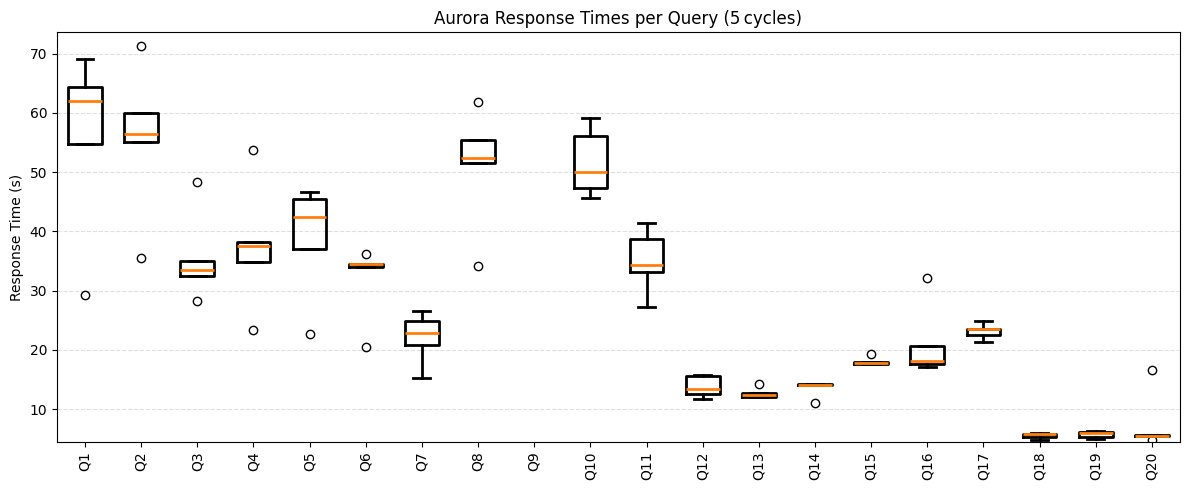

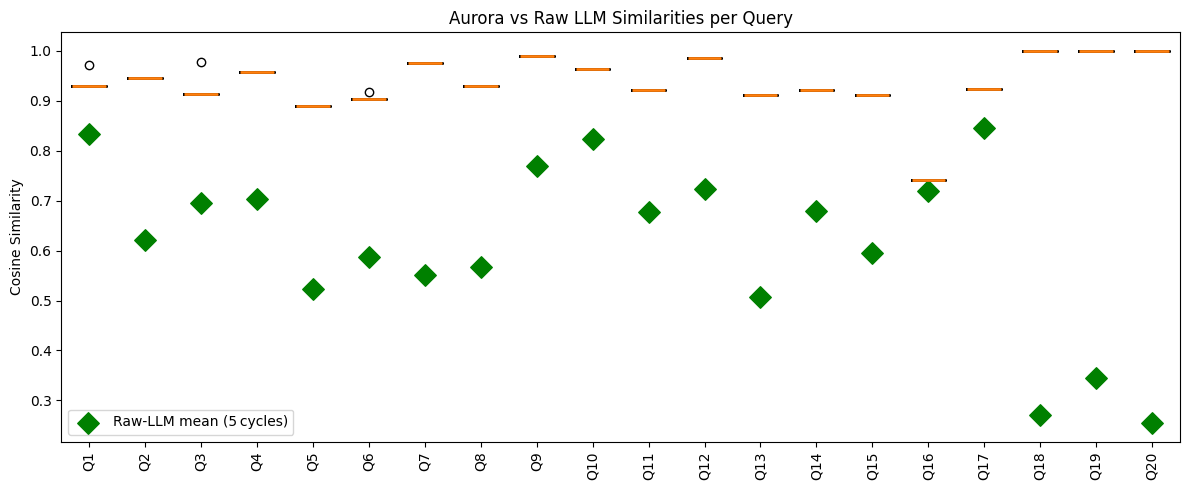

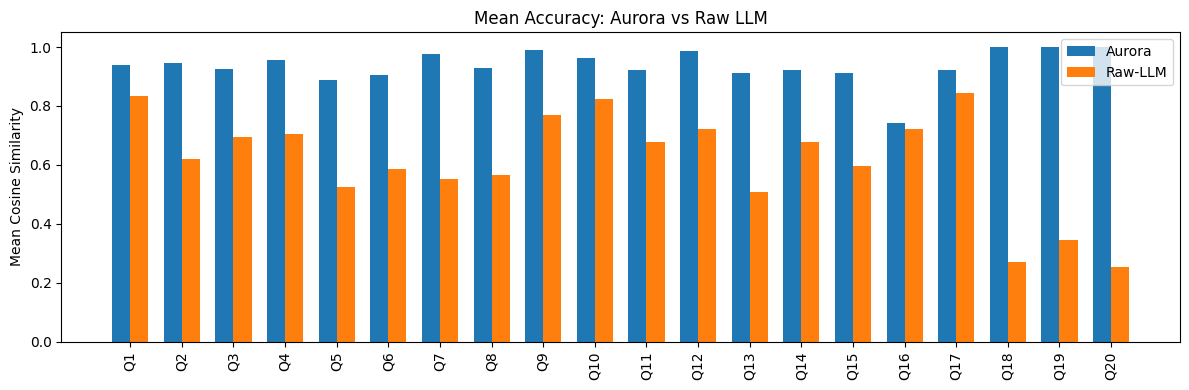

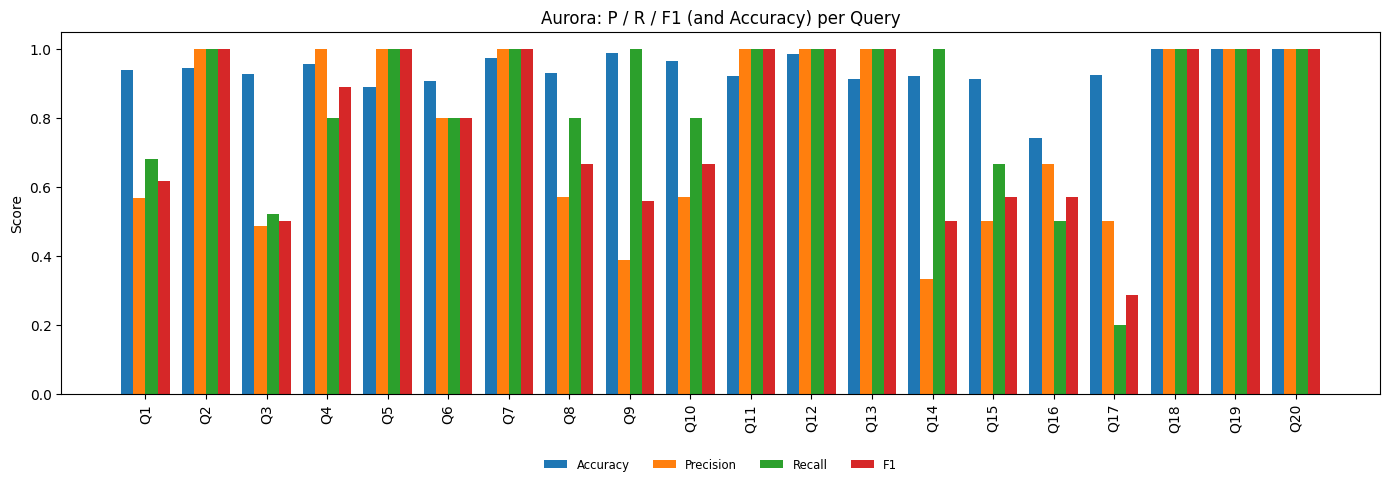

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ── prepare labels and grouping ───────────────────────────────────
Q = summary.shape[0]
labels = [f"Q{i+1}" for i in summary["query_index"]]

# build per‐query distributions over the 5 cycles
time_dist = [
    test_df.loc[test_df["query_index"] == i, "aurora_time_mean"].values
    for i in summary["query_index"]
]
acc_dist = [
    test_df.loc[test_df["query_index"] == i, "aurora_acc_mean"].values
    for i in summary["query_index"]
]

# pull the cycle‐means from summary
raw_time_means = summary["raw_time_mean_mean"].values
raw_acc_means  = summary["raw_acc_mean_mean"].values

# ── 8.1 Aurora response times boxplot (across cycles) ─────────────
plt.figure(figsize=(12,5))
plt.boxplot(
    time_dist,
    widths=0.6,
    tick_labels=labels,
    boxprops   = dict(linewidth=2),
    whiskerprops=dict(linewidth=2),
    capprops   = dict(linewidth=2),
    medianprops=dict(linewidth=2),
)
plt.xticks(rotation=90)
plt.ylabel("Response Time (s)")
plt.title("Aurora Response Times per Query (5 cycles)")
# zoom in to 5–95th percentile of *all* obs:
all_times = np.concatenate(time_dist)
low, high = np.percentile(all_times, [5, 95])
plt.ylim(low - 1, high + 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# ── 8.2 Aurora vs Raw cosine‐similarity boxplot + Raw‐mean overlay ──
plt.figure(figsize=(12,5))
plt.boxplot(
    acc_dist,
    widths=0.6,
    tick_labels=labels,
    boxprops   = dict(linewidth=2),
    whiskerprops=dict(linewidth=2),
    capprops   = dict(linewidth=2),
    medianprops=dict(linewidth=2),
)
plt.scatter(
    np.arange(1, Q+1),
    raw_acc_means,
    color="green", marker="D", s=120,
    label="Raw‐LLM mean (5 cycles)"
)
plt.xticks(rotation=90)
plt.ylabel("Cosine Similarity")
plt.title("Aurora vs Raw LLM Similarities per Query")
plt.legend()
plt.tight_layout()
plt.show()


# ── 8.3 Bar chart: mean accuracy Aurora vs Raw ────────────────────
x = np.arange(Q)
width = 0.35
plt.figure(figsize=(12,4))
plt.bar(x - width/2, summary["aurora_acc_mean_mean"], width, label="Aurora")
plt.bar(x + width/2, summary["raw_acc_mean_mean"],   width, label="Raw‐LLM")
plt.xticks(x, labels, rotation=90)
plt.ylabel("Mean Cosine Similarity")
plt.title("Mean Accuracy: Aurora vs Raw LLM")
plt.legend()
plt.tight_layout()
plt.show()


# ── 8.4 Grouped bar chart: Aurora’s metrics per query ─────────────
metrics      = ["aurora_acc_mean_mean", "aurora_prec_mean_mean",
                "aurora_rec_mean_mean",  "aurora_f1_mean_mean"]
metric_labels= ["Accuracy","Precision","Recall","F1"]
x = np.arange(Q)
width = 0.2

plt.figure(figsize=(14,5))
for i,(col,lbl) in enumerate(zip(metrics, metric_labels)):
    plt.bar(x + (i-1.5)*width,
            summary[col],
            width,
            label=lbl)

plt.xticks(x, labels, rotation=90)
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.title("Aurora: P / R / F1 (and Accuracy) per Query")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=False,
    fontsize='small'
)
plt.tight_layout()
plt.show()


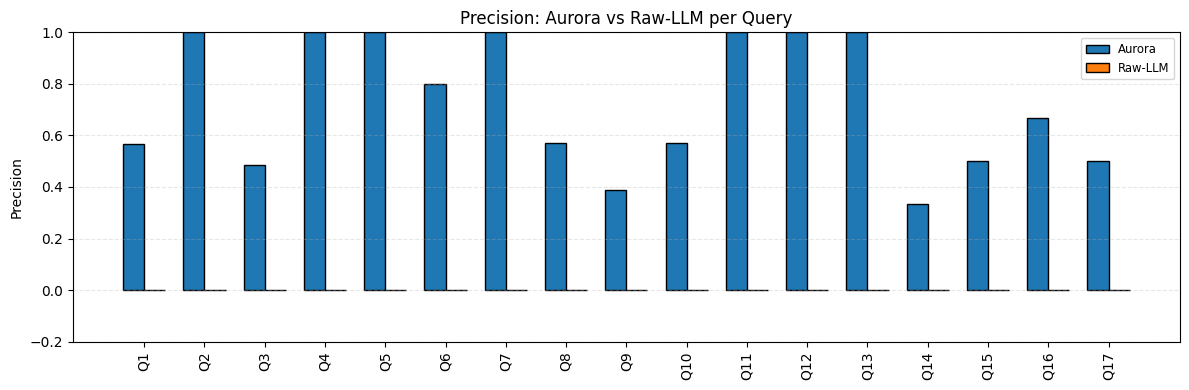

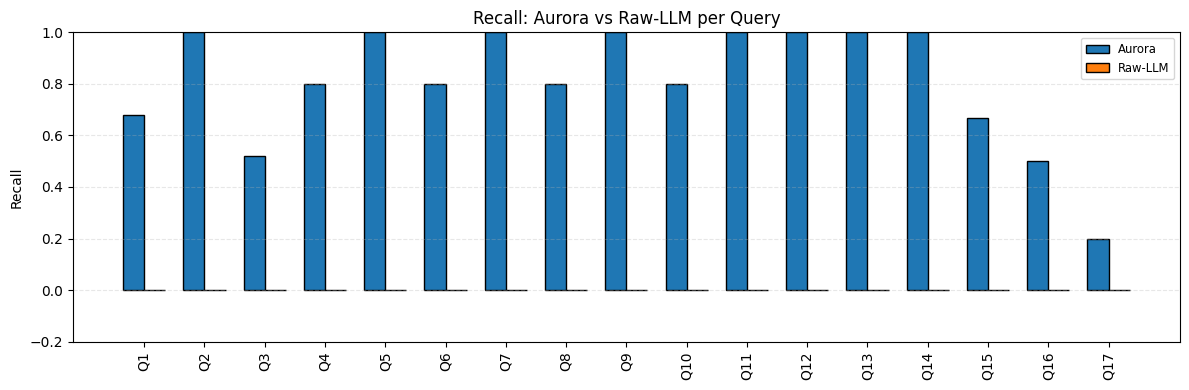

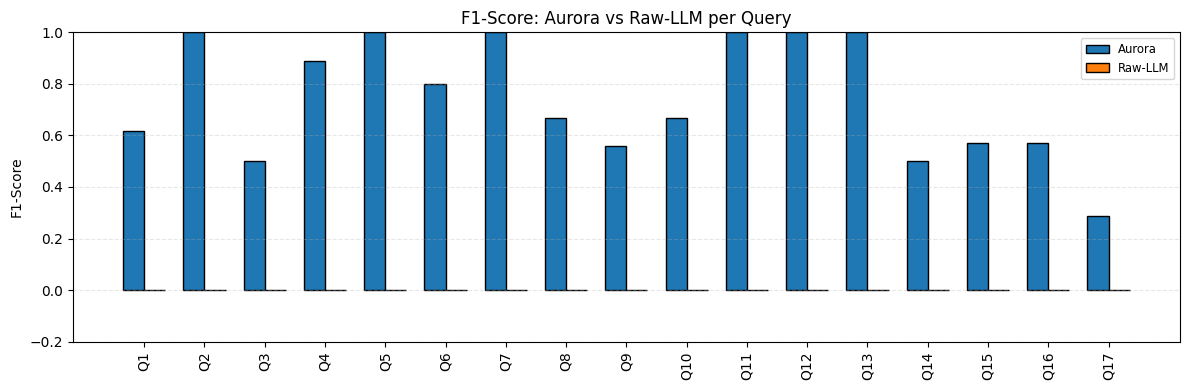

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- load & aggregate (as before) ---
df = pd.read_csv("evaluation_cycles_full.csv")
summary = (
    df
    .groupby("query_index")
    .agg({
        "aurora_prec_mean": ["mean","std"],
        "raw_prec":         ["mean","std"],
        "aurora_rec_mean":  ["mean","std"],
        "raw_rec":          ["mean","std"],
        "aurora_f1_mean":   ["mean","std"],
        "raw_f1":           ["mean","std"],
    })
)
summary.columns = ["_".join(c) for c in summary.columns]
summary = summary.reset_index()

# drop the last three (true‐negatives)
summary = summary[summary.query_index < 17]

# prep
n      = len(summary)
x      = np.arange(n)
labels = [f"Q{q+1}" for q in summary.query_index]
w      = 0.35

def plot_bars(a_col, r_col, ylabel, title):
    plt.figure(figsize=(12,4))
    # Aurora bars (blue)
    plt.bar(x - w/2,
            summary[a_col],
            width=w,
            label="Aurora",
            color="#1f77b4",
            edgecolor="black",
            linewidth=1)
    # Raw-LLM bars (orange) – now with an edge so you can see the zero‐height ones
    plt.bar(x + w/2,
            summary[r_col],
            width=w,
            label="Raw-LLM",
            color="#ff7f0e",
            edgecolor="black",
            linewidth=1)

    plt.xticks(x, labels, rotation=90)
    plt.ylim(-0.2, 1.0)
    plt.ylabel(ylabel)
    plt.title(title)
    # legend inside upper-right, with its box
    plt.legend(loc="upper right", fontsize="small", frameon=True)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()



# --- three separate plots ---
plot_bars("aurora_prec_mean_mean", "raw_prec_mean", "Precision",
          "Precision: Aurora vs Raw-LLM per Query")

plot_bars("aurora_rec_mean_mean",  "raw_rec_mean",  "Recall",
          "Recall: Aurora vs Raw-LLM per Query")

plot_bars("aurora_f1_mean_mean",   "raw_f1_mean",   "F1-Score",
          "F1-Score: Aurora vs Raw-LLM per Query")
